In [ ]:
# **Exploratory Data Analysis:**

The libraries needed for our exploratory data analysis were imported, and the Consumer Financial Protection Bureau complaint CSV dataset was read into a pandas DataFrame called df. Exploratory Data Analysis (EDA) is performed to understand the main characteristics, patterns, and relationships within the dataset. The data was properly cleaned before visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"CFPB_Consumer_Complaints_2024 (1).csv")

In [3]:
df.head()

,date_received,product,subproduct,issue,subissue,consumer_complaint_narrative,company_public_response,company_name,state,zip_code,tags,consumer_consent_provided,submitted_via,date_sent_to_company,company_response_to_consumer,timely_response,consumer_disputed,complaint_id
0,10/16/2020,"Credit reporting, credit repair services, or o...",Credit repair services,Fraud or scam,NaN,NaN,NaN,ERC,NaN,NaN,NaN,NaN,Phone,10/19/2020,Closed with explanation,True,NaN,3903929
1,10/24/2014,Credit reporting,NaN,Incorrect information on credit report,Account terms,NaN,NaN,ERC,LA,70816.0,"Older American, Servicemember",NaN,Web,10/29/2014,Closed with non-monetary relief,True,False,1085252
2,3/14/2015,Credit reporting,NaN,Incorrect information on credit report,Account terms,NaN,NaN,ERC,AL,35242.0,NaN,NaN,Web,3/20/2015,Closed with non-monetary relief,True,False,1283279
3,7/13/2015,Debt collection,"Other (i.e. phone, health club, etc.)",Cont'd attempts collect debt not owed,Debt was paid,"During my time as an employee for XXXX, I was ...",Company believes it acted appropriately as aut...,ERC,CO,80916.0,NaN,Consent provided,Web,7/13/2015,Closed with non-monetary relief,True,False,1465916
4,9/21/2018,Debt collection,Other debt,Attempts to collect debt not owed,Debt was paid,NaN,Company believes it acted appropriately as aut...,ERC,KY,41008.0,NaN,Consent not provided,Web,9/21/2018,Closed with explanation,True,NaN,3025580


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   date_received                 500 non-null    object 
 1   product                       500 non-null    object 
 2   subproduct                    494 non-null    object 
 3   issue                         500 non-null    object 
 4   subissue                      499 non-null    object 
 5   consumer_complaint_narrative  200 non-null    object 
 6   company_public_response       231 non-null    object 
 7   company_name                  500 non-null    object 
 8   state                         492 non-null    object 
 9   zip_code                      492 non-null    float64
 10  tags                          63 non-null     object 
 11  consumer_consent_provided     382 non-null    object 
 12  submitted_via                 500 non-null    object 
 13  date_

In [5]:
df.shape

(500, 18)

In [6]:
df.dtypes

date_received                    object
product                          object
subproduct                       object
issue                            object
subissue                         object
consumer_complaint_narrative     object
company_public_response          object
company_name                     object
state                            object
zip_code                        float64
tags                             object
consumer_consent_provided        object
submitted_via                    object
date_sent_to_company             object
company_response_to_consumer     object
timely_response                    bool
consumer_disputed                object
complaint_id                      int64
dtype: object

In [7]:
df.isnull().sum()

date_received                     0
product                           0
subproduct                        6
issue                             0
subissue                          1
consumer_complaint_narrative    300
company_public_response         269
company_name                      0
state                             8
zip_code                          8
tags                            437
consumer_consent_provided       118
submitted_via                     0
date_sent_to_company              0
company_response_to_consumer      0
timely_response                   0
consumer_disputed               271
complaint_id                      0
dtype: int64

In [8]:
df["consumer_complaint_narrative"].isna().sum()

np.int64(300)

# **Text characteristics:**
A copy of the original DataFrame (df_text) was created for examining the characteristics of our complaint narratives to prevent changing our main dataset. Examining the text characteristics helps us understand and calculates the total number of complaints, the number with missing narratives, and the percentage missing. This helps explain why the modeling dataset is much smaller than the original dataset (due to high amount of missing complaint). Additionally, the basic characteristics of each complaint narrative, including character count, word count, average word length, number of digits, and number of uppercase characters were calculated which helped to describe the variability of the written complaints before modeling.

In [9]:
df_text = df.copy()

In [10]:
print("Total complaints:", len(df_text))

missing_complaint_narratives = df_text["consumer_complaint_narrative"].isna().sum()

print("Missing complaint narratives:", missing_complaint_narratives)

print(
    "Percentage missing:",
    round((missing_complaint_narratives / len(df_text)) * 100, 2),
    "%"
)

Total complaints: 500
Missing complaint narratives: 300
Percentage missing: 60.0 %


In [11]:
df_text["filled_complaint_narrative"] = (
    df_text["consumer_complaint_narrative"].notna()
)

print(df_text["filled_complaint_narrative"].value_counts())


filled_complaint_narrative
False    300
True     200
Name: count, dtype: int64


In [12]:
df_text["consumer_complaint_narrative"] = (
    df_text["consumer_complaint_narrative"]
    .fillna("")
    .astype(str)
)

In [13]:
def extract_text_features(text):
    words = text.split()

    char_count = len(text)
    word_count = len(words)

    avg_word_length = (
        np.mean([len(word) for word in words])
        if len(words) > 0
        else 0
    )

    num_digits = sum(char.isdigit() for char in text)
    num_uppercase = sum(char.isupper() for char in text)

    return pd.Series({
        "char_count": char_count,
        "word_count": word_count,
        "avg_word_length": avg_word_length,
        "num_digits": num_digits,
        "num_uppercase": num_uppercase
    })

In [14]:
text_features = df_text["consumer_complaint_narrative"].apply(
    extract_text_features
)

df_text = pd.concat(
    [df_text, text_features],
    axis=1
)

In [15]:
df_text[
    [
        "consumer_complaint_narrative",
        "char_count",
        "word_count",
        "avg_word_length",
        "num_digits",
        "num_uppercase"
    ]
].head()

,consumer_complaint_narrative,char_count,word_count,avg_word_length,num_digits,num_uppercase
0,,0.0,0.0,0.000000,0.0,0.0
1,,0.0,0.0,0.000000,0.0,0.0
2,,0.0,0.0,0.000000,0.0,0.0
3,"During my time as an employee for XXXX, I was ...",2423.0,440.0,4.495455,2.0,90.0
4,,0.0,0.0,0.000000,0.0,0.0


In [16]:
df_text[
    [
        "char_count",
        "word_count",
        "avg_word_length",
        "num_digits",
        "num_uppercase"
    ]
].describe()

,char_count,word_count,avg_word_length,num_digits,num_uppercase
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,306.796000,55.462000,1.819374,2.494000,26.830000
std,609.521849,109.834876,2.259946,6.930948,63.960198
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,379.250000,70.250000,4.396154,0.000000,22.250000
max,4096.000000,769.000000,9.500000,61.000000,653.000000


In [17]:
consumer_complaint_narrative_df = df_text[
    df_text["filled_complaint_narrative"] == True
].copy()

consumer_complaint_narrative_df[
    [
        "char_count",
        "word_count",
        "avg_word_length",
        "num_digits",
        "num_uppercase"
    ]
].describe()

,char_count,word_count,avg_word_length,num_digits,num_uppercase
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,766.990000,138.655000,4.548434,6.235000,67.075000
std,759.509515,136.590964,0.575810,9.849612,86.862563
min,20.000000,2.000000,2.426667,0.000000,0.000000
25%,265.000000,48.000000,4.249381,0.000000,15.000000
50%,559.500000,100.500000,4.497727,2.000000,35.500000
75%,965.250000,173.250000,4.819537,9.000000,83.000000
max,4096.000000,769.000000,9.500000,61.000000,653.000000


In [18]:
#drop the missing customer complaints
df = df.dropna(subset=["consumer_complaint_narrative"])

In [19]:
df["consumer_complaint_narrative"].isna().sum()

np.int64(0)

In [20]:
 df["product"].isnull().sum()

np.int64(0)

In [21]:
 df["consumer_complaint_narrative"].isnull().sum()

np.int64(0)

In [671]:
df.duplicated().sum()

np.int64(0)

In [672]:
print("Rows remaining:", len(df))
print("Columns remaining:", len(df.columns))

Rows remaining: 200
Columns remaining: 18


In [673]:
df.shape

(200, 18)

In [674]:
df.nunique()

date_received                   192
product                           3
subproduct                        5
issue                            12
subissue                         24
consumer_complaint_narrative    200
company_public_response           4
company_name                      1
state                            39
zip_code                        197
tags                              3
consumer_consent_provided         1
submitted_via                     1
date_sent_to_company            192
company_response_to_consumer      3
timely_response                   2
consumer_disputed                 2
complaint_id                    200
dtype: int64

In [675]:
df.describe()

,zip_code,complaint_id
count,199.000000,2.000000e+02
mean,52644.994975,3.081253e+06
std,29280.786920,1.279346e+06
min,1118.000000,1.295307e+06
25%,30273.000000,2.062538e+06
50%,44087.000000,2.893812e+06
75%,79435.000000,3.859637e+06
max,98503.000000,6.275970e+06


In [676]:
df["product"].value_counts()

product
Debt collection                                                                 166
Credit reporting, credit repair services, or other personal consumer reports     33
Credit reporting                                                                  1
Name: count, dtype: int64

In [22]:
product_percent = df["product"].value_counts(normalize=True) * 100
print(product_percent.round(2))

product
Debt collection                                                                 83.0
Credit reporting, credit repair services, or other personal consumer reports    16.5
Credit reporting                                                                 0.5
Name: proportion, dtype: float64


The **bar chart** below displays the percentage of complaints belonging to each product category. It provides a visual illustration of class imbalance.

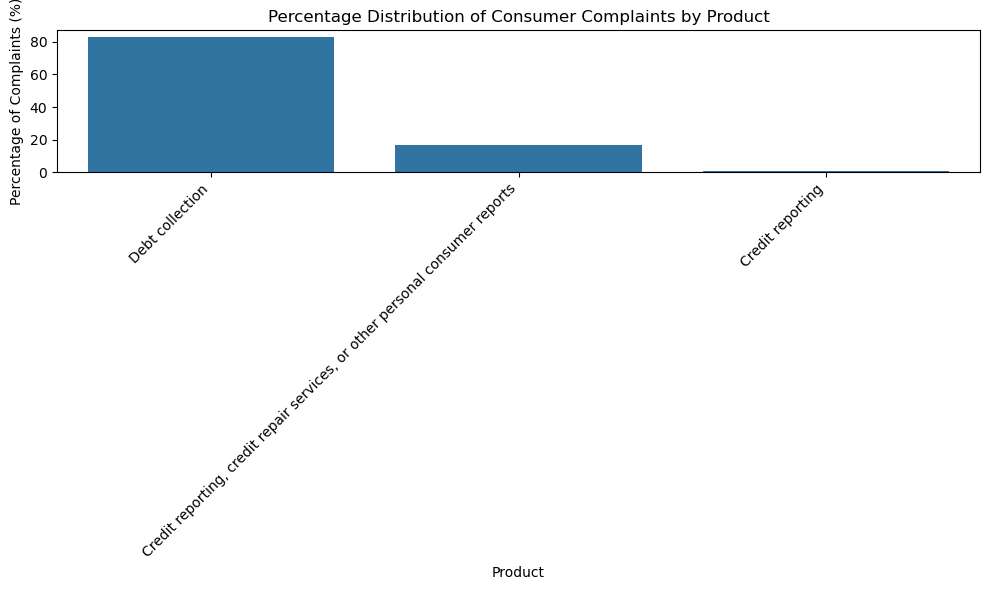

In [26]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=product_percent.index,
    y=product_percent.values
)

plt.title("Percentage Distribution of Consumer Complaints by Product")
plt.xlabel("Product")
plt.ylabel("Percentage of Complaints (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# **Time Patterns:**
The received and sent dates were converted into proper datetime objects. Correct date types are necessary for reliable time-based EDA and for identifying trends across years and months.

In [30]:
# Convert dates to datetime
df["date_received_dt"] = pd.to_datetime(
    df["date_received"],
    errors="coerce"
)

df["date_sent_to_company_dt"] = pd.to_datetime(
    df["date_sent_to_company"],
    errors="coerce"
)

In [31]:
#Creating time variables
#yearR- Year received
#yearS- Year sent
df["yearR"] = df["date_received_dt"].dt.year
df["yearS"] = df["date_sent_to_company_dt"].dt.year

In [32]:
#monthR- month received
#monthS- month sent
df["monthR"] = df["date_received_dt"].dt.month
df["monthS"] = df["date_sent_to_company_dt"].dt.month

In [33]:
yearly_received_complaints = df["yearR"].value_counts().sort_index()
print(yearly_received_complaints)

yearR
2015    38
2016    22
2017    25
2018    24
2019    17
2020    29
2021    29
2022    16
Name: count, dtype: int64


In [34]:
yearly_sent_complaints = df["yearS"].value_counts().sort_index()
print(yearly_sent_complaints)

yearS
2015    37
2016    23
2017    25
2018    24
2019    17
2020    29
2021    28
2022    17
Name: count, dtype: int64


**The bar chart below shows how the number of received complaints changes across years.**

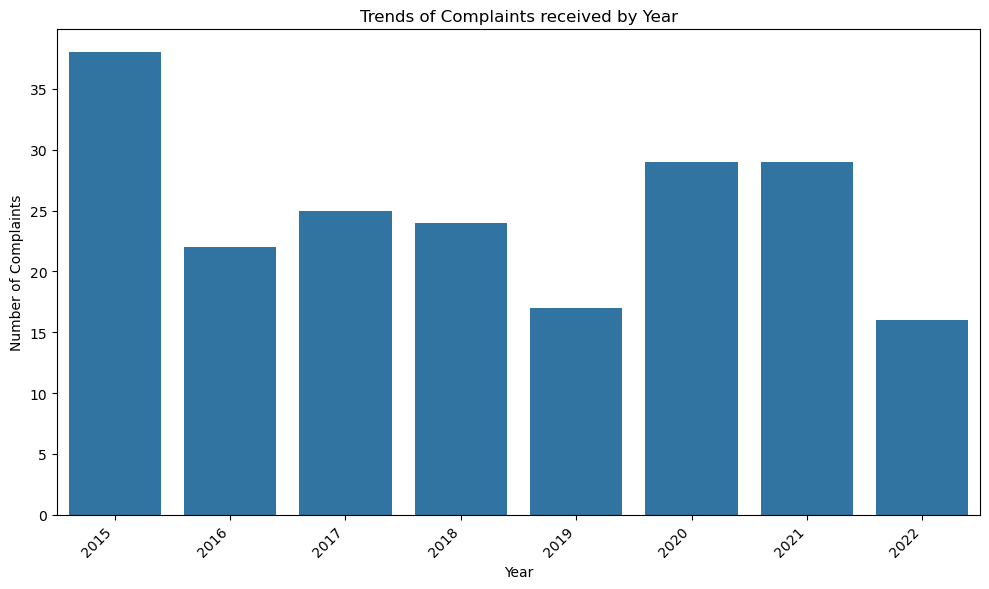

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=yearly_received_complaints.index,
    y=yearly_received_complaints.values
)

plt.title("Trends of Complaints received by Year")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**The chart shows the yearly distribution of complaints sent to companies. It helps to identify the differences in timing within the complaint workflow.**

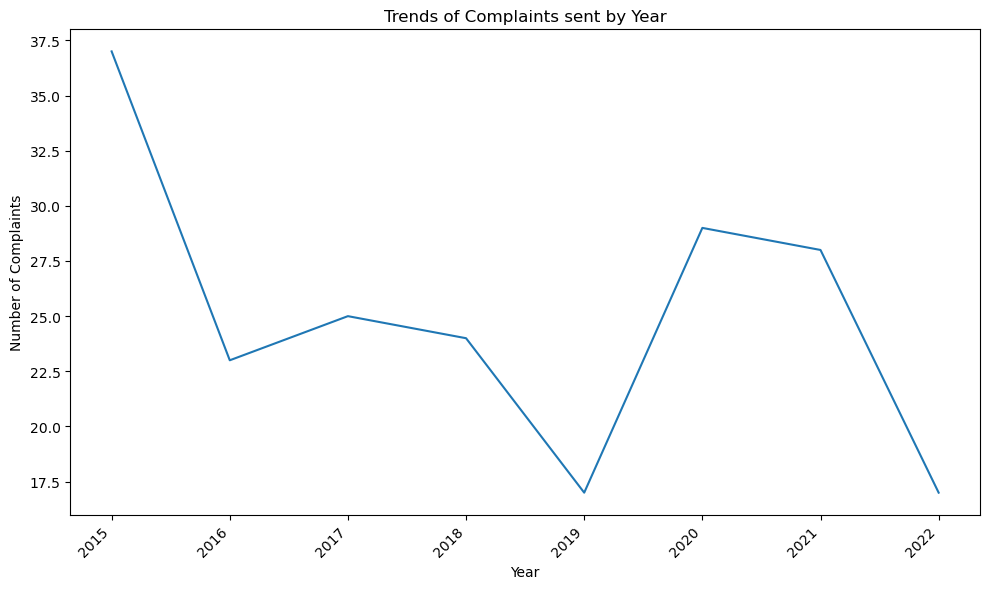

In [36]:
plt.figure(figsize=(10, 6))

plt.plot(
    yearly_sent_complaints.index,
    yearly_sent_complaints.values
)

plt.title("Trends of Complaints sent by Year")
plt.xlabel("Year")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [37]:
#monthR- month received
#monthS- month sent
df["monthR"] = df["date_received_dt"].dt.month
df["monthS"] = df["date_sent_to_company_dt"].dt.month

In [38]:
monthly_received_complaints = df["monthR"].value_counts().sort_index()

print(monthly_received_complaints)

monthR
1     23
2      9
3     19
4     26
5     21
6     13
7     24
8     14
9     11
10    13
11     9
12    18
Name: count, dtype: int64


In [39]:
monthly_sent_complaints = df["monthS"].value_counts().sort_index()

print(monthly_sent_complaints)

monthS
1     21
2     13
3     17
4     25
5     23
6     14
7     24
8     13
9     12
10    12
11    10
12    16
Name: count, dtype: int64


**The charts below  displays the number of complaints received monthly and sent monthly respectively.**

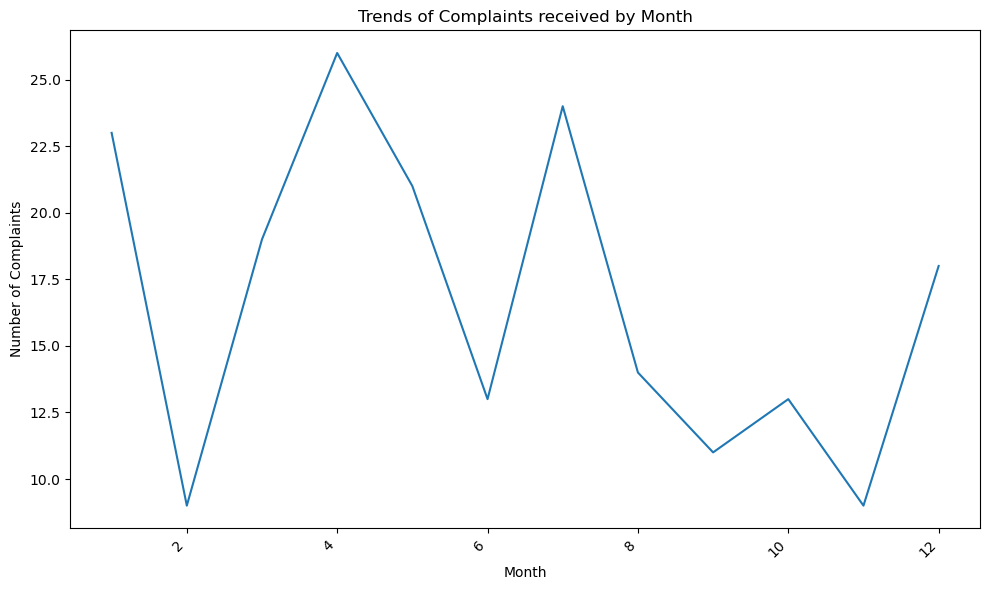

In [40]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_received_complaints.index,
    monthly_received_complaints.values
)

plt.title("Trends of Complaints received by Month")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

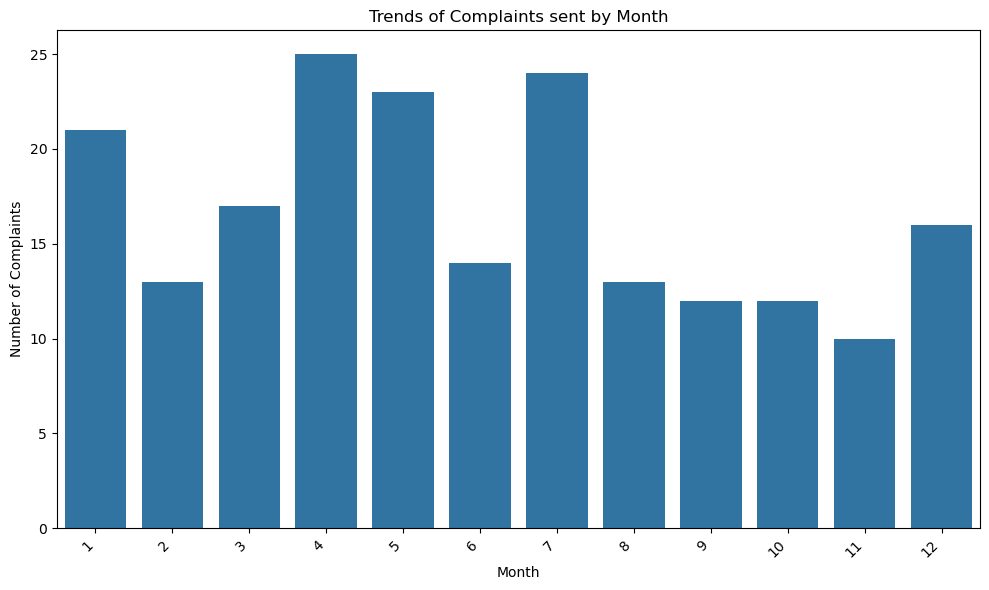

In [41]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=monthly_sent_complaints.index,
    y=monthly_sent_complaints.values
)

plt.title("Trends of Complaints sent by Month")
plt.xlabel("Month")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**The cross-tabulation below compares complaint products by year.**

C:\Users\USER\AppData\Local\Temp\ipykernel_25120\3824270306.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


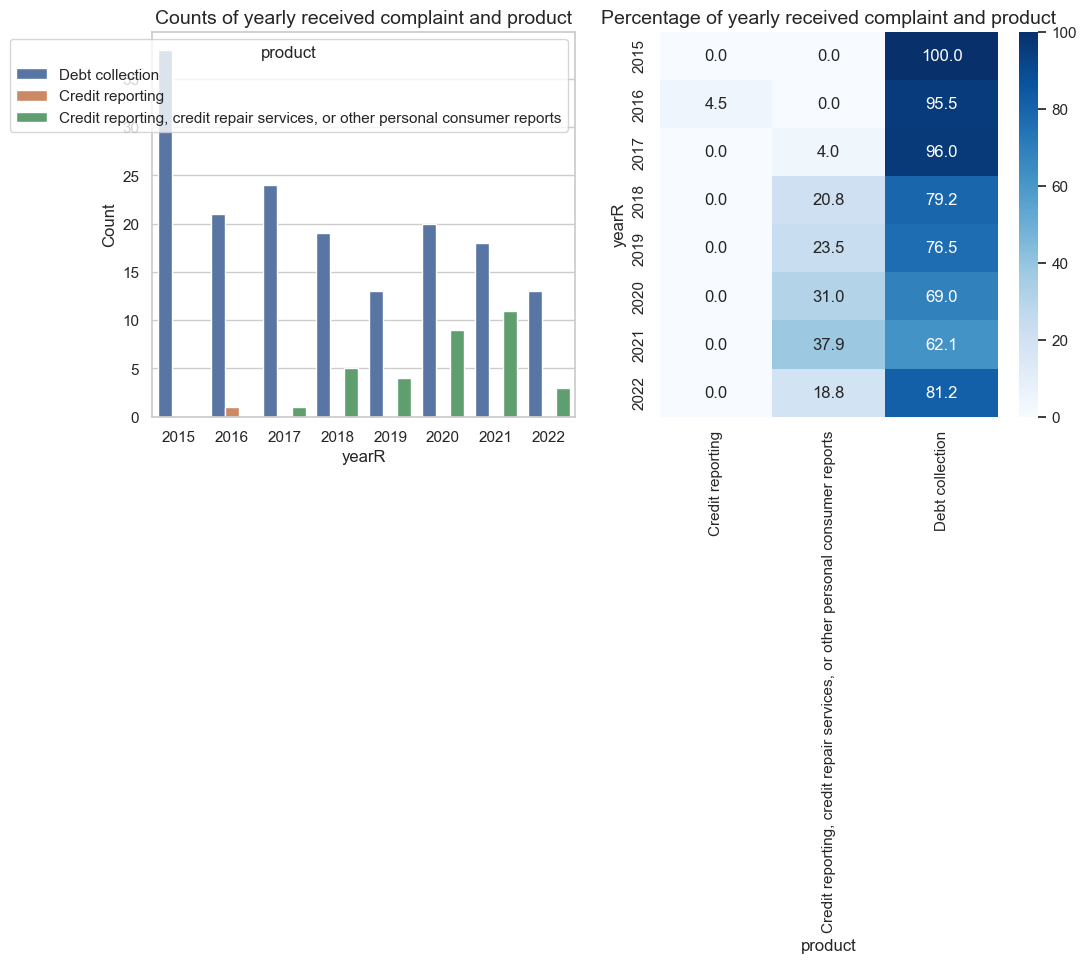

In [42]:
cross_tab = pd.crosstab(df["yearR"], df["product"])
cross_tab_percent = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100


sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#  Grouped Bar Chart (Counts) 
sns.countplot(x="yearR", hue="product", data=df, ax=axes[0])
axes[0].set_title("Counts of yearly received complaint and product", fontsize=14)
axes[0].set_xlabel("yearR", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].legend(title="product")

#  Heatmap (Percentages) 
sns.heatmap(cross_tab_percent, annot=True, fmt=".1f", cmap="Blues", ax=axes[1])
axes[1].set_title("Percentage of yearly received complaint and product", fontsize=14)
axes[1].set_xlabel("product", fontsize=12)
axes[1].set_ylabel("yearR", fontsize=12)


plt.tight_layout()
plt.show()

# **Channel representation:**
Tis an important part of the data critique because a heavily represented channel may dominate the sample and may not represent all complaint-submission behavior.Hence, the distribution of complaints by submitted_via (such as Web or Phone) was checked. 

In [692]:
print(df.columns)

Index(['date_received', 'product', 'subproduct', 'issue', 'subissue',
       'consumer_complaint_narrative', 'company_public_response',
       'company_name', 'state', 'zip_code', 'tags',
       'consumer_consent_provided', 'submitted_via', 'date_sent_to_company',
       'company_response_to_consumer', 'timely_response', 'consumer_disputed',
       'complaint_id', 'date_received_dt', 'date_sent_to_company_dt', 'yearR',
       'yearS', 'monthR', 'monthS'],
      dtype='object')


In [43]:
#channel breakdown(submitted_via)
channel_counts = df_text["submitted_via"].value_counts()

channel_counts


submitted_via
Web            464
Phone           25
Referral         5
Postal mail      4
Fax              2
Name: count, dtype: int64

In [44]:
channel_percent = df_text["submitted_via"].value_counts(normalize=True) * 100
print(channel_percent.round(2))

submitted_via
Web            92.8
Phone           5.0
Referral        1.0
Postal mail     0.8
Fax             0.4
Name: proportion, dtype: float64


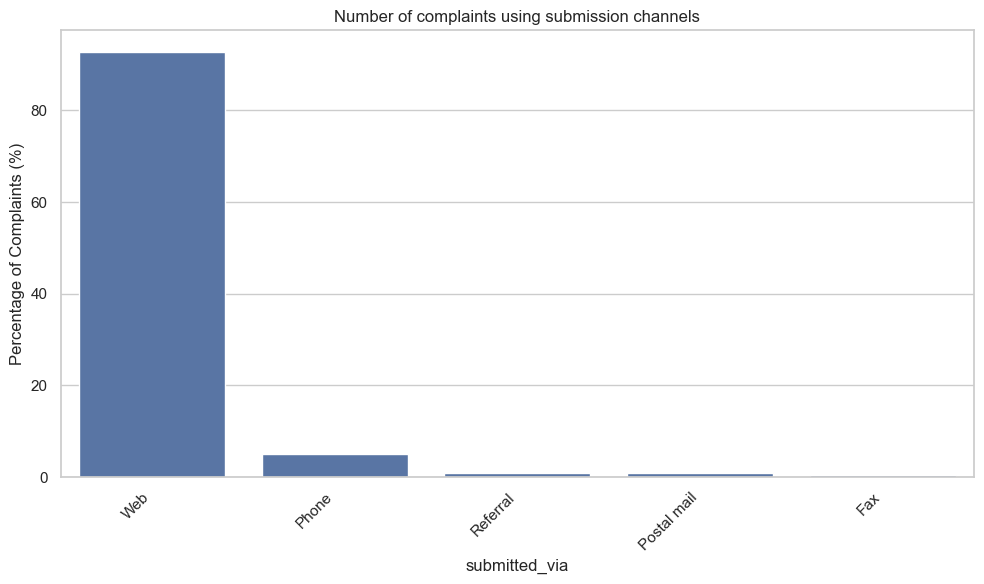

In [45]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=channel_percent.index,
    y=channel_percent.values
)

plt.title("Number of complaints using submission channels")
plt.xlabel("submitted_via")
plt.ylabel("Percentage of Complaints (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

**The count and percentage comparisons between submission channel and product was analyzed. The analysis helps identify whether certain products are disproportionately represented within particular channels, which could affect model performance and fairness.**

C:\Users\USER\AppData\Local\Temp\ipykernel_25120\3139338420.py:23: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


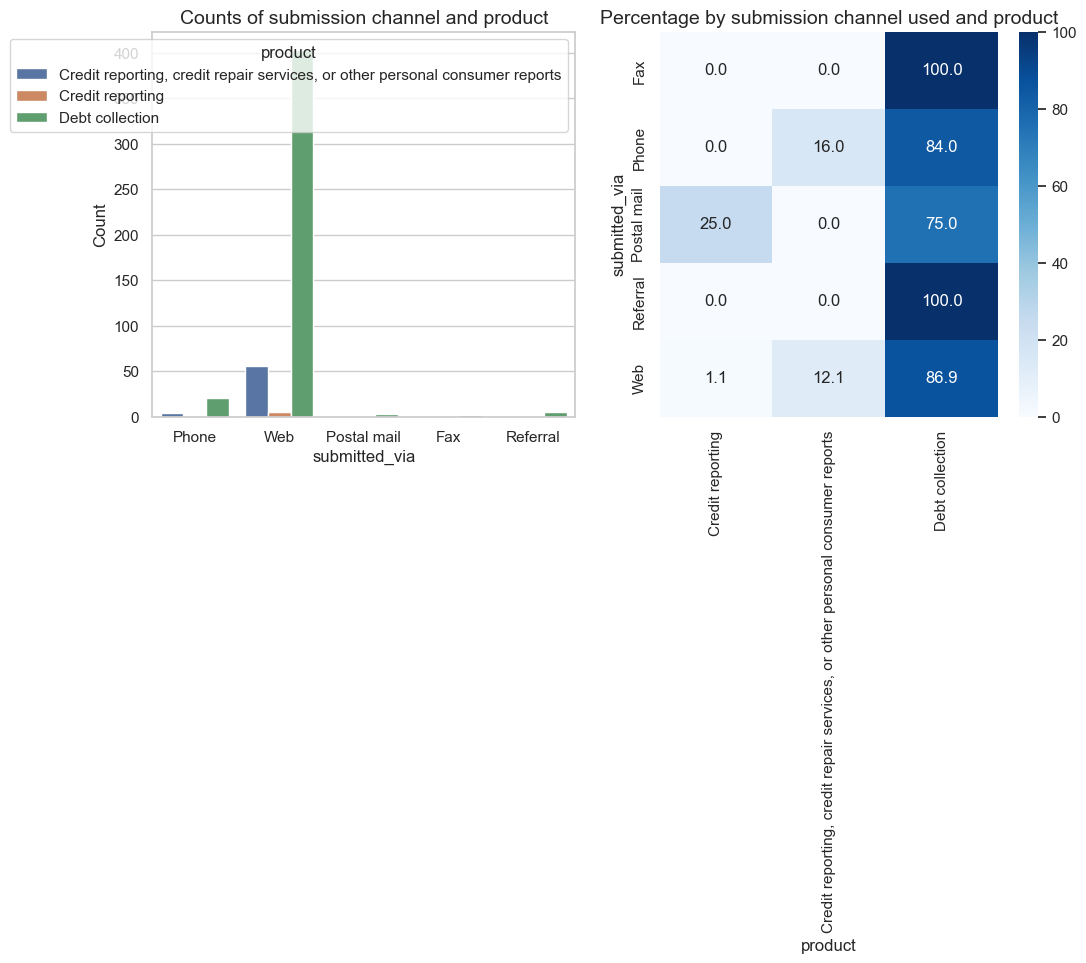

In [46]:
cross_tab = pd.crosstab(df_text["submitted_via"], df_text["product"])
cross_tab_percent = cross_tab.div(cross_tab.sum(axis=1), axis=0) * 100


sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

#  Grouped Bar Chart (Counts) 
sns.countplot(x="submitted_via", hue="product", data=df_text, ax=axes[0])
axes[0].set_title("Counts of submission channel and product", fontsize=14)
axes[0].set_xlabel("submitted_via", fontsize=12)
axes[0].set_ylabel("Count", fontsize=12)
axes[0].legend(title="product")

#  Heatmap (Percentages) 
sns.heatmap(cross_tab_percent, annot=True, fmt=".1f", cmap="Blues", ax=axes[1])
axes[1].set_title("Percentage by submission channel used and product", fontsize=14)
axes[1].set_xlabel("product", fontsize=12)
axes[1].set_ylabel("submitted_via", fontsize=12)


plt.tight_layout()
plt.show()

# **Geographic representation**

In [50]:
print("Unique states:", df["state"].nunique())
print("Missing state values:", df["state"].isna().sum())

state_counts = df["state"].fillna("Unknown").value_counts()

state_counts.head(15)

Unique states: 39
Missing state values: 1


state
FL    27
CA    27
TX    22
PA    13
GA    10
NY     8
NV     7
OH     6
TN     6
CO     5
MD     5
MI     4
VA     4
KY     4
MA     3
Name: count, dtype: int64

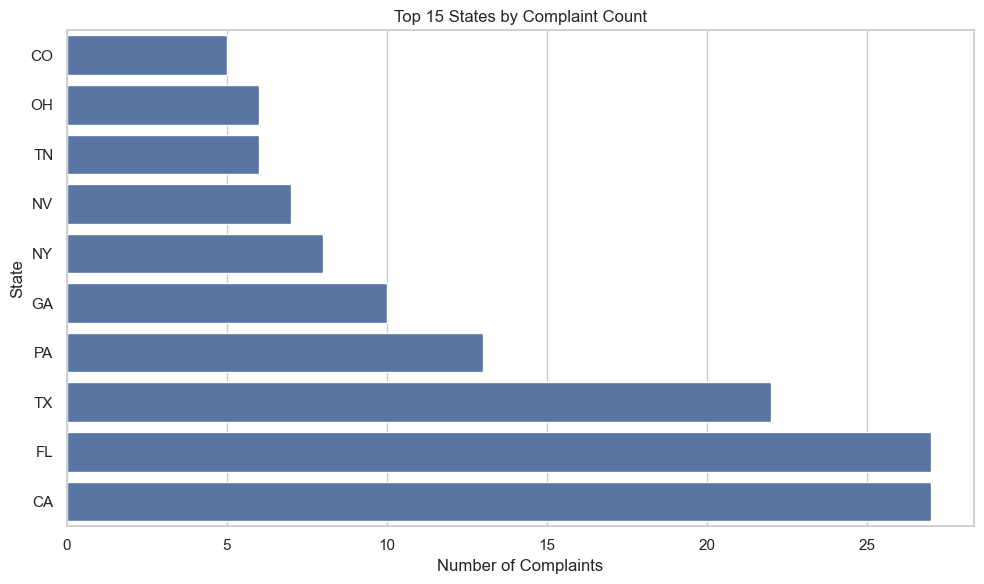

In [51]:
plt.figure(figsize=(10, 6))

top_states = state_counts.head(10).sort_values()

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 15 States by Complaint Count")
plt.xlabel("Number of Complaints")
plt.ylabel("State")
plt.tight_layout()
plt.show()

**Baseline Approach:**
It predicts the most frequent product for every test complaint. The baseline provides a minimum benchmark. Because the product classes are imbalanced, **Macro F1** is used as the main comparison metric rather than accuracy alone.


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

X = df["consumer_complaint_narrative"]
y = df["product"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

most_frequent_class = y_train.value_counts().idxmax()
y_pred_baseline = [most_frequent_class] * len(y_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_macro_f1 = f1_score(y_test, y_pred_baseline, average="macro", zero_division=0)

print(f"Most frequent class: {most_frequent_class}")
print(f"Baseline Accuracy: {baseline_accuracy:.2f}")
print(f"Baseline Macro F1: {baseline_macro_f1:.2f}")


Most frequent class: Debt collection
Baseline Accuracy: 0.80
Baseline Macro F1: 0.44


**Alternative Approach:** 
keyword groups and weights were defined for complaint priority scoring. It looks for signals such as fraud, unauthorized activity, financial loss, legal threats, and customer distress. This is an alternative business approach to the project.

In [54]:
#Alternative (priority scoring)
import re

URGENT_KEYWORDS = {
    "fraud_security": {
        "keywords": [
            "fraud",
            "scam",
            "unauthorized",
            "identity theft",
            "phishing",
            "compromised",
            "hacked"
        ],
        "weight": 5
    },

    "account_access": {
        "keywords": [
            "account locked",
            "cannot access",
            "login failed",
            "blocked",
            "frozen",
            "suspended"
        ],
        "weight": 4
    },

    "financial_loss": {
        "keywords": [
            "money missing",
            "funds not received",
            "payment failed",
            "overcharged",
            "double charged",
            "urgent",
            "immediately"
        ],
        "weight": 4
    },

    "legal_threats": {
        "keywords": [
            "lawsuit",
            "legal action",
            "report to authorities",
            "complaint to regulator",
            "breach of contract"
        ],
        "weight": 3
    },

    "customer_distress": {
        "keywords": [
            "emergency",
            "life savings",
            "cannot pay bills",
            "eviction",
            "medical emergency"
        ],
        "weight": 3
    }
}


def calculate_priority_score(complaint_text):
    # Convert the value to a string
    text = str(complaint_text).strip().lower()

    # If the text is empty, return zero
    if not text:
        return 0, []

    score = 0
    matched_keywords = []

    for category, data in URGENT_KEYWORDS.items():
        for keyword in data["keywords"]:
            if re.search(rf"\b{re.escape(keyword)}\b", text):
                score += data["weight"]
                matched_keywords.append(keyword)

    return score, matched_keywords


def classify_priority(score):

    if score >= 8:
        return "High"

    elif score >= 4:
        return "Medium"

    else:
        return "Low"


In [55]:
df["priority_score"] = df[
    "consumer_complaint_narrative"
].apply(
    lambda x: calculate_priority_score(x)[0]
)

In [56]:
df["priority"] = df["priority_score"].apply(
    classify_priority
)

In [57]:
df[
    [
        "consumer_complaint_narrative",
        "priority_score",
        "priority"
    ]
].head(10)

,consumer_complaint_narrative,priority_score,priority
3,"During my time as an employee for XXXX, I was ...",4,Medium
9,I have been monitoring my credit weekly for 2 ...,0,Low
11,I previously had phone service with XXXX XXXX....,0,Low
13,Several debt collectors have called me on beha...,3,Low
16,On XX/XX/2020 I settled and paid a debt with E...,0,Low
20,It is showing on my credit report that i owe m...,0,Low
22,Set up an payment agreement to pay and remove ...,0,Low
25,"On XX/XX/2021, I contacted ERC regarding an XX...",0,Low
26,"Enhanced Recovery Corporation, XXXX, FL XXXX. ...",3,Low
28,This is a debt from XXXX that has already been...,0,Low


In [58]:
df["priority"].value_counts()

priority
Low       151
Medium     32
High       17
Name: count, dtype: int64

In [59]:
priority_count=df["priority"].value_counts()

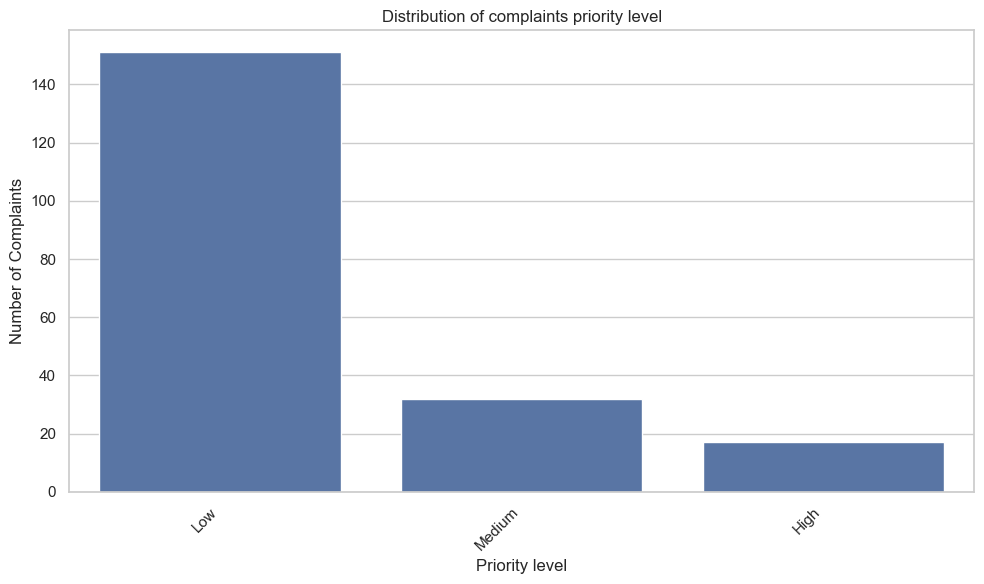

In [60]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=priority_count.index,
    y=priority_count.values
)

plt.title("Distribution of complaints priority level")
plt.xlabel("Priority level")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [61]:
from sklearn.model_selection import train_test_split
X = df['consumer_complaint_narrative']
y = df['product']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('classifier', LogisticRegression(max_iter=1000, class_weight= "balanced"))
])

In [63]:
model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [64]:
import numpy as np
logistic_probabilities = model.predict_proba(X_test)
logistic_classes = model.named_steps["classifier"].classes_

logistic_predictions = logistic_classes[
    np.argmax(logistic_probabilities, axis=1)
]
max_confidence = logistic_probabilities.max(axis=1)
threshold_rows = []
for threshold in [0.50, 0.60, 0.70, 0.80, 0.90]:
    auto_mask = max_confidence >= threshold
    auto_count = auto_mask.sum()
    review_count = len(auto_mask) - auto_count

    if auto_count > 0:
        auto_accuracy = accuracy_score(
            y_test.iloc[auto_mask],
            logistic_predictions[auto_mask]
        )
    else:
        auto_accuracy = np.nan

    threshold_rows.append({
        "Threshold": threshold,
        "Auto-routed": auto_count,
        "Human-review": review_count,
        "Auto-route coverage": auto_count / len(y_test),
        "Auto-route accuracy": auto_accuracy
    })

threshold_results = pd.DataFrame(threshold_rows)
threshold_results

,Threshold,Auto-routed,Human-review,Auto-route coverage,Auto-route accuracy
0,0.5,38,2,0.950,0.789474
1,0.6,17,23,0.425,0.764706
2,0.7,3,37,0.075,1.000000
3,0.8,1,39,0.025,1.000000
4,0.9,0,40,0.000,NaN


In [65]:
y_pred = model.predict(X_test)

In [66]:
from sklearn.metrics import classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
f1score = f1_score(y_test, y_pred, average="macro", zero_division=0)

print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1 Score:", f1score)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

print(f"\nBaseline Macro F1: {baseline_macro_f1:.2f}")
print(f"Model Macro F1: {f1score:.2f}")


Macro Precision: 0.6385281385281385
Macro Recall: 0.625
Macro F1 Score: 0.6307692307692307
Accuracy: 0.775

Classification Report:
                                                                              precision    recall  f1-score   support

Credit reporting, credit repair services, or other personal consumer reports       0.43      0.38      0.40         8
                                                             Debt collection       0.85      0.88      0.86        32

                                                                    accuracy                           0.78        40
                                                                   macro avg       0.64      0.62      0.63        40
                                                                weighted avg       0.76      0.78      0.77        40


Baseline Macro F1: 0.44
Model Macro F1: 0.63


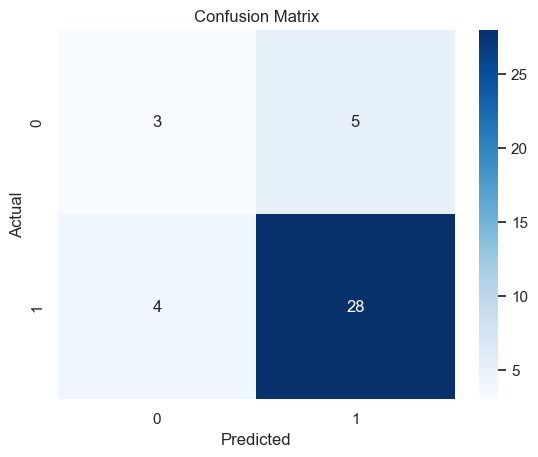

In [67]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [68]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head()

,Actual,Predicted
263,"Credit reporting, credit repair services, or o...","Credit reporting, credit repair services, or o..."
42,Debt collection,Debt collection
77,Debt collection,Debt collection
393,Debt collection,Debt collection
335,Debt collection,Debt collection


In [69]:
from sklearn.model_selection import train_test_split
X = df['consumer_complaint_narrative']
y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('classifier', LogisticRegression(max_iter=1000, class_weight= "balanced"))
])

In [71]:
model.fit(X_train, y_train)

,steps,"[('tfidf', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [72]:
import numpy as np
logistic_probabilities = model.predict_proba(X_test)
logistic_classes = model.named_steps["classifier"].classes_

logistic_predictions = logistic_classes[
    np.argmax(logistic_probabilities, axis=1)
]
max_confidence = logistic_probabilities.max(axis=1)
threshold_rows = []
for threshold in [0.50, 0.60, 0.70, 0.80, 0.90]:
    auto_mask = max_confidence >= threshold
    auto_count = auto_mask.sum()
    review_count = len(auto_mask) - auto_count

    if auto_count > 0:
        auto_accuracy = accuracy_score(
            y_test.iloc[auto_mask],
        logistic_predictions[auto_mask]
        )
    else:
        auto_accuracy = np.nan

    threshold_rows.append({
        "Threshold": threshold,
        "Auto-routed": auto_count,
        "Human-review": review_count,
        "Auto-route coverage": auto_count / len(y_test),
        "Auto-route accuracy": auto_accuracy
    })

threshold_results = pd.DataFrame(threshold_rows)
threshold_results

,Threshold,Auto-routed,Human-review,Auto-route coverage,Auto-route accuracy
0,0.5,19,21,0.475,0.894737
1,0.6,5,35,0.125,1.000000
2,0.7,1,39,0.025,1.000000
3,0.8,0,40,0.000,NaN
4,0.9,0,40,0.000,NaN


In [73]:
y_pred = model.predict(X_test)

In [74]:
from sklearn.metrics import classification_report
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred,average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1score = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1score)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,zero_division=0))

Precision: 0.74875
Recall: 0.75
F1 Score: 0.7487012987012986
Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

        High       0.25      0.33      0.29         3
         Low       0.90      0.90      0.90        31
      Medium       0.20      0.17      0.18         6

    accuracy                           0.75        40
   macro avg       0.45      0.47      0.46        40
weighted avg       0.75      0.75      0.75        40



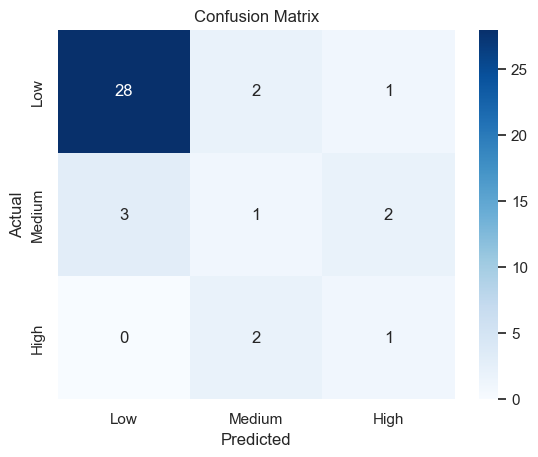

In [75]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=["Low", "Medium", "High"])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Low", "Medium", "High"],
    yticklabels=["Low", "Medium", "High"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [76]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head()

,Actual,Predicted
263,Low,Low
42,Low,Low
77,Medium,Low
393,Low,Low
335,Low,Low


# **Data critique:**
1. Consumer narratives: 
A large share of complaints do not contain narratives. Therefore, the text model applies only to a selected subset of complaints. Hence, we do not have access to all complaints and this model might not recognize the witheld/missing complaints when applied in a standard business setting with the fuull information. This model is limited to the complaints we have access to.

2. Severe class imbalance:
Majority of the consumer complaints were classified into to debt collection in the product category. Hence, other products are minority and the accuracy can hide the minority class performance.

3. Channel representation:
The web submission channel dominates the dataset, and performance may reflect that channel more strongly than less-represented channels.

4. Geographic representation:
States are not necessarily represented equally. A model evaluated on this sample should not automatically be assumed to generalize equally across all geographic areas in the US and also it doesn't represent the customer complaints in other parts of the world.

5. Limited sample size:
After cleaning the dataset, the sample size dropped from 500 to 200 because of the high number of missing customer complaint. Hence, the model trained with this dataset might not perform well with extreemely large dataset.

6. Initial categorizaton/routing: The model focused on consumer complaint and products category because those are the deciding factors needed for the initial routing to the teams that determine the response time interval, company response to customer,and complaints disputed. Hence, those columns were not used as features when training the model to prevent data leakage.

# **Decision log**
1. Problem definition: Consumer complaints contain unstructured textual descriptions. Manual categorization can require staff to read and interpret individual complaints and may lead to inconsistent routing. This project therefore investigates whether complaint narratives can be used to predict the financial product category and support initial complaint routing. The system is intended to support, not replace, human complaint-handling personnel.

2. Target variable: The product category is the target variable and the consumer complaint narrative is the main feature. This allows the model to examine the complaint text and predict its product category for initial routing. An alternative approach, priority scoring, was considered because it focuses on urgency signals, but keyword-based scoring can miss synonyms and different ways consumers describe the same issue.

3. Success metric: Macro F1 is the main success metric, supported by precision, recall, and accuracy. Macro F1 gives equal importance to each class and is more appropriate than accuracy because the product classes are imbalanced. A model could obtain high accuracy by mainly predicting the majority class while performing poorly on minority classes.

4. Class Imbalance Handling: The target classes are heavily imbalanced, with one product category containing substantially more complaints than the other. The Logistic Regression model therefore uses **class_weight="balanced"** so that minority classes receive more attention during training. The limitation is that class weighting does not create new information for minority classes and cannot fully compensate for limited minority-class examples.

5. Threshold or Confidence Policy: A threshold of **0.50** was selected because it provides a practical balance between automation and human review on the test set. At 0.50, **38 of 40 complaints (95%)** meet the confidence threshold and 2 complaints (5%) are referred for review. Higher thresholds reduce coverage substantially: 42.5% at 0.60, 7.5% at 0.70, and 2.5% at 0.80. The threshold is therefore used as a decision-support policy rather than permission for fully automatic routing. Incorrect routing may cause delayed or inappropriate handling, so human oversight remains necessary.

6. Deployment Reality: The proposed model would be used by customer-service teams responsible for receiving and routing consumer complaints. The system would provide a predicted product category and confidence score. High-confidence cases can receive a routing recommendation, while unclear cases should be reviewed by staff. If adoption is only partial, some complaints may be routed manually and others with model assistance, so consistent procedures and regular monitoring are needed.


# **Business Recommendation**

The model should not be deployed as a fully automated routing system yet. It should be used as a decision-support tool to assist staff with initial complaint categorization, while staff retain the final routing decision.

A confidence threshold of **0.50** is recommended as the starting policy because it provided **95% automatic-routing coverage on the test set**, while the remaining 5% were referred for human review. This threshold should be monitored and adjusted if later data show that the error rate or class performance changes.

The model should be monitored regularly using **Macro F1, precision, recall, accuracy, and the proportion of complaints automatically routed versus sent for human review**. Performance should be reviewed as new complaint data become available because changes in complaint patterns may reduce model performance over time. The model can then be retrained when sufficient new data are available.
